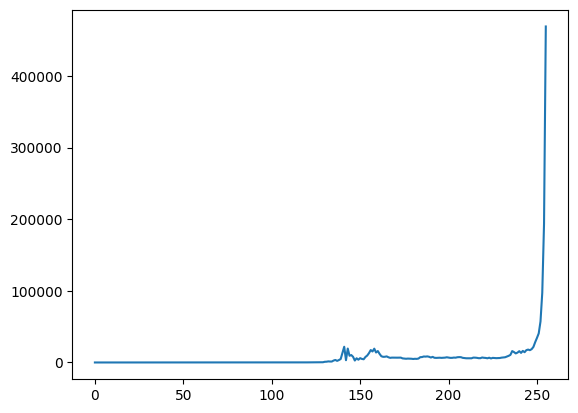

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
img = cv2.imread('../assets/images/1.jpg', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 分析图片的频率
hist = cv2.calcHist([img], [0], None, [256], [0, 256])
plt.plot(hist)
plt.show()

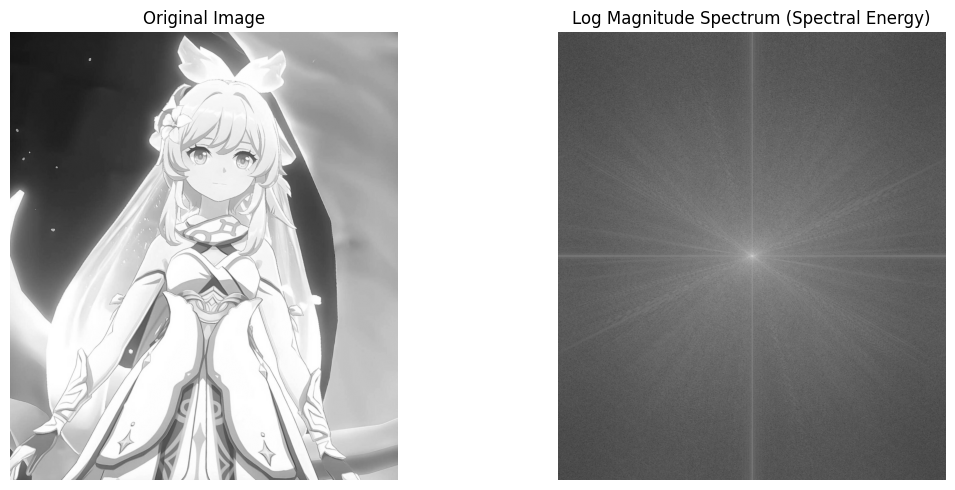

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像
img = cv2.imread('../assets/images/1.jpg', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 转为灰度图（光谱分析通常在单通道进行）
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# 进行二维傅里叶变换
f = np.fft.fft2(gray)

# 将零频分量移到频谱中心
f_shift = np.fft.fftshift(f)

# 计算幅度谱（光谱能量）
magnitude_spectrum = np.abs(f_shift)

# 为更好可视化，取对数尺度
log_magnitude = np.log(magnitude_spectrum + 1e-8)  # 加小量避免 log(0)

# 绘图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(log_magnitude, cmap='gray')
plt.title('Log Magnitude Spectrum (Spectral Energy)')
plt.axis('off')

plt.tight_layout()
plt.show()

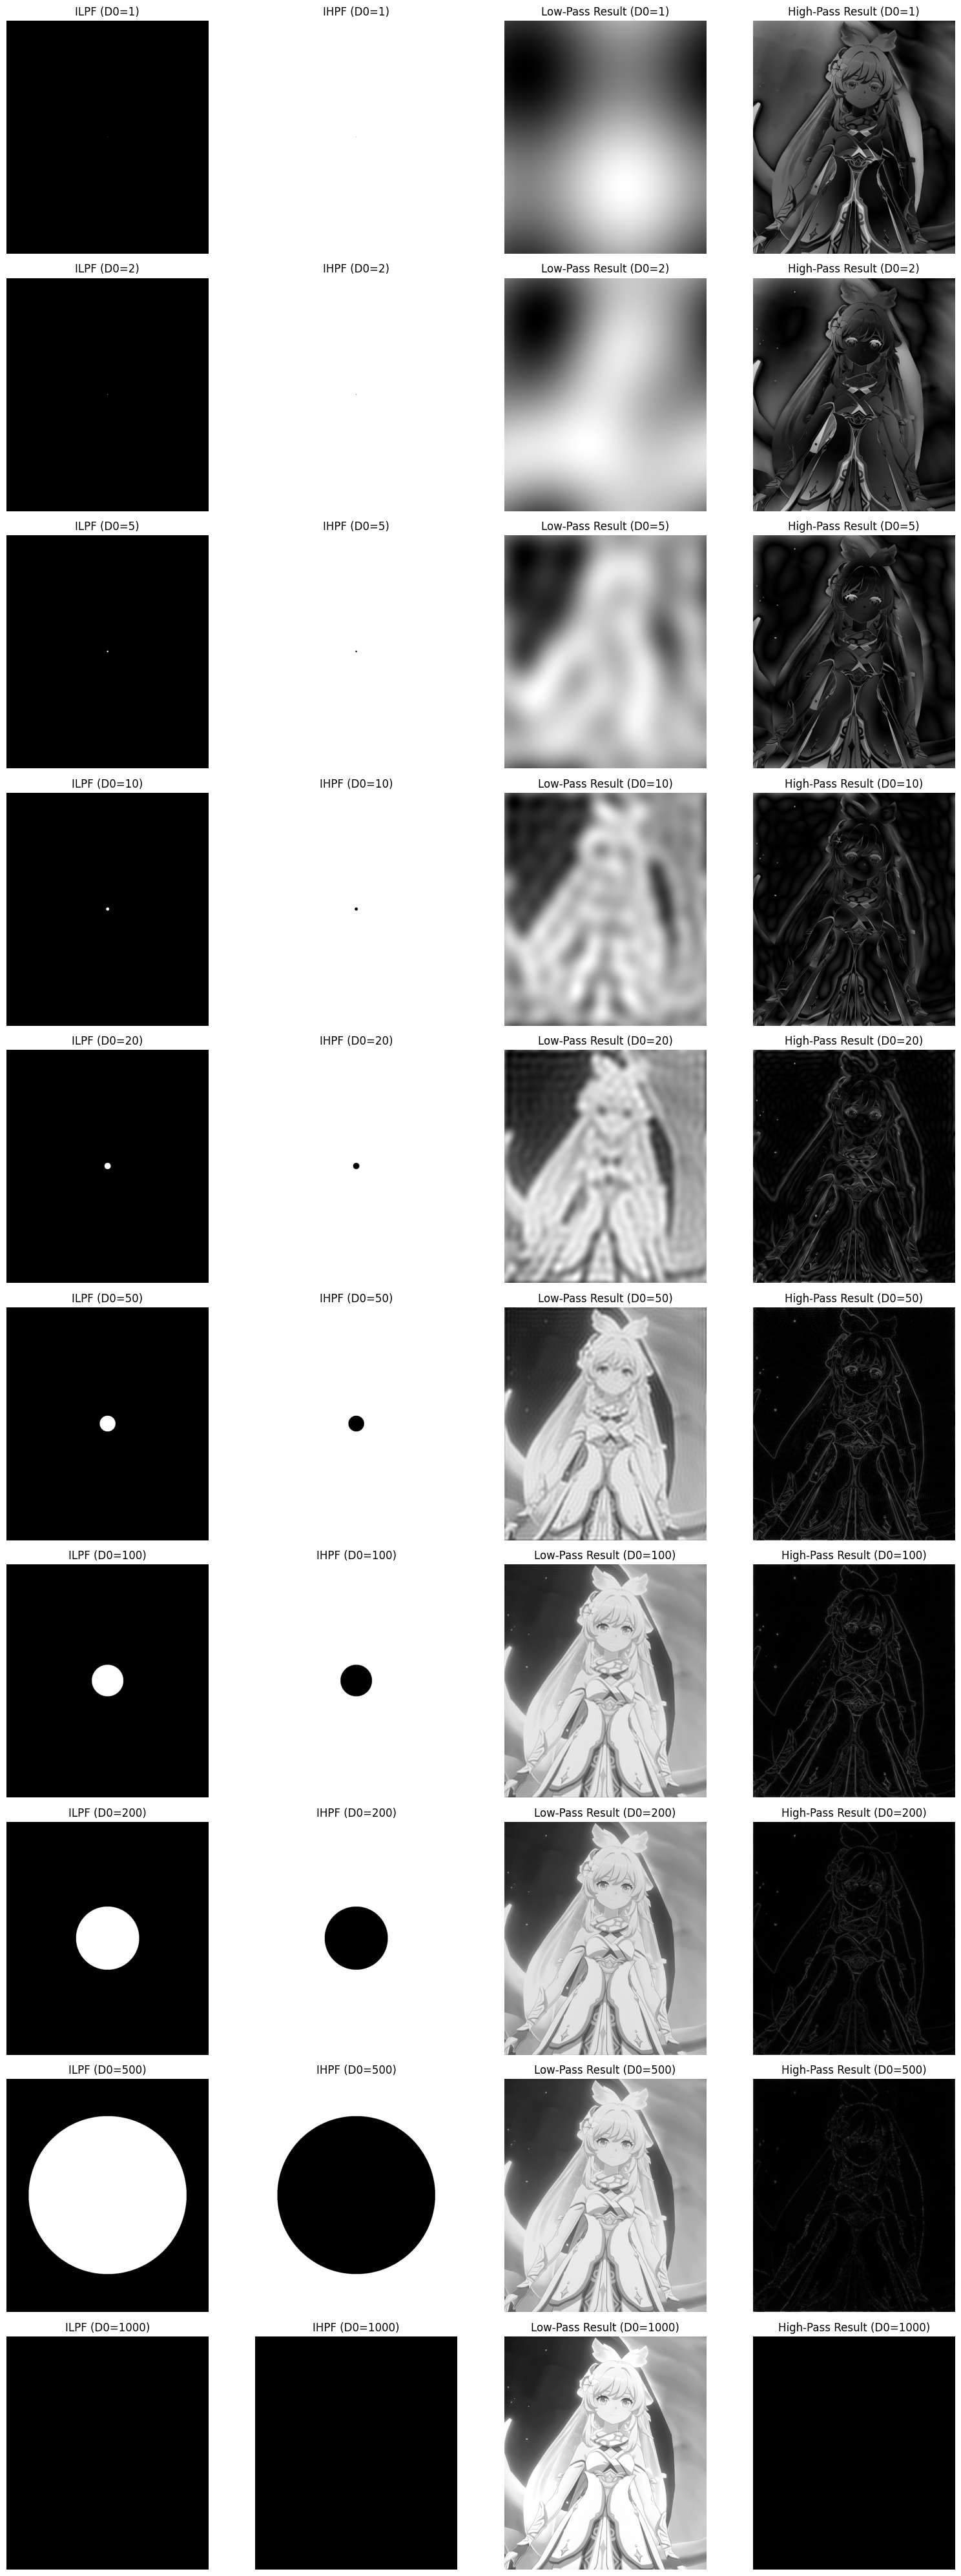

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像并转为灰度
img = cv2.imread('../assets/images/1.jpg', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
rows, cols = gray.shape

# 傅里叶变换
f = np.fft.fft2(gray)
f_shift = np.fft.fftshift(f)

# 构建理想低通滤波器（ILPF）
def ideal_low_pass_filter(shape, cutoff):
    P, Q = shape
    H = np.zeros((P, Q))
    center = (P // 2, Q // 2)
    for u in range(P):
        for v in range(Q):
            D = np.sqrt((u - center[0])**2 + (v - center[1])**2)
            if D <= cutoff:
                H[u, v] = 1
    return H

# 构建理想高通滤波器（IHPF） = 1 - ILPF
def ideal_high_pass_filter(shape, cutoff):
    return 1 - ideal_low_pass_filter(shape, cutoff)

# 定义截止频率列表
cutoffs = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

# 计算子图布局 - 修正计算方式
n_freq = len(cutoffs)
n_plots_per_freq = 4  # 每个频率需要4个图：ILPF, IHPF, 低通结果, 高通结果
total_plots = n_freq * n_plots_per_freq

# 为了更好的显示效果，使用 n_plots_per_freq 列
n_cols = n_plots_per_freq
n_rows = int(np.ceil(total_plots / n_cols))

plt.figure(figsize=(16, 4 * n_rows))

idx = 1  # 从第1个子图开始放置滤波结果

for i, D0 in enumerate(cutoffs):
    # 应用滤波器
    H_low = ideal_low_pass_filter((rows, cols), D0)
    H_high = ideal_high_pass_filter((rows, cols), D0)

    # 频域滤波
    G_low = f_shift * H_low
    G_high = f_shift * H_high

    # 逆变换回空域
    g_low = np.abs(np.fft.ifft2(np.fft.ifftshift(G_low)))
    g_high = np.abs(np.fft.ifft2(np.fft.ifftshift(G_high)))

    # 低通滤波器
    plt.subplot(n_rows, n_cols, idx)
    plt.imshow(H_low, cmap='gray')
    plt.title(f'ILPF (D0={D0})')
    plt.axis('off')
    idx += 1

    # 高通滤波器
    plt.subplot(n_rows, n_cols, idx)
    plt.imshow(H_high, cmap='gray')
    plt.title(f'IHPF (D0={D0})')
    plt.axis('off')
    idx += 1

    # 低通滤波后的图像
    plt.subplot(n_rows, n_cols, idx)
    plt.imshow(g_low, cmap='gray')
    plt.title(f'Low-Pass Result (D0={D0})')
    plt.axis('off')
    idx += 1

    # 高通滤波后的图像
    plt.subplot(n_rows, n_cols, idx)
    plt.imshow(g_high, cmap='gray')
    plt.title(f'High-Pass Result (D0={D0})')
    plt.axis('off')
    idx += 1

plt.tight_layout()
plt.savefig('../output/理想滤波器.png', dpi=300)
plt.show()

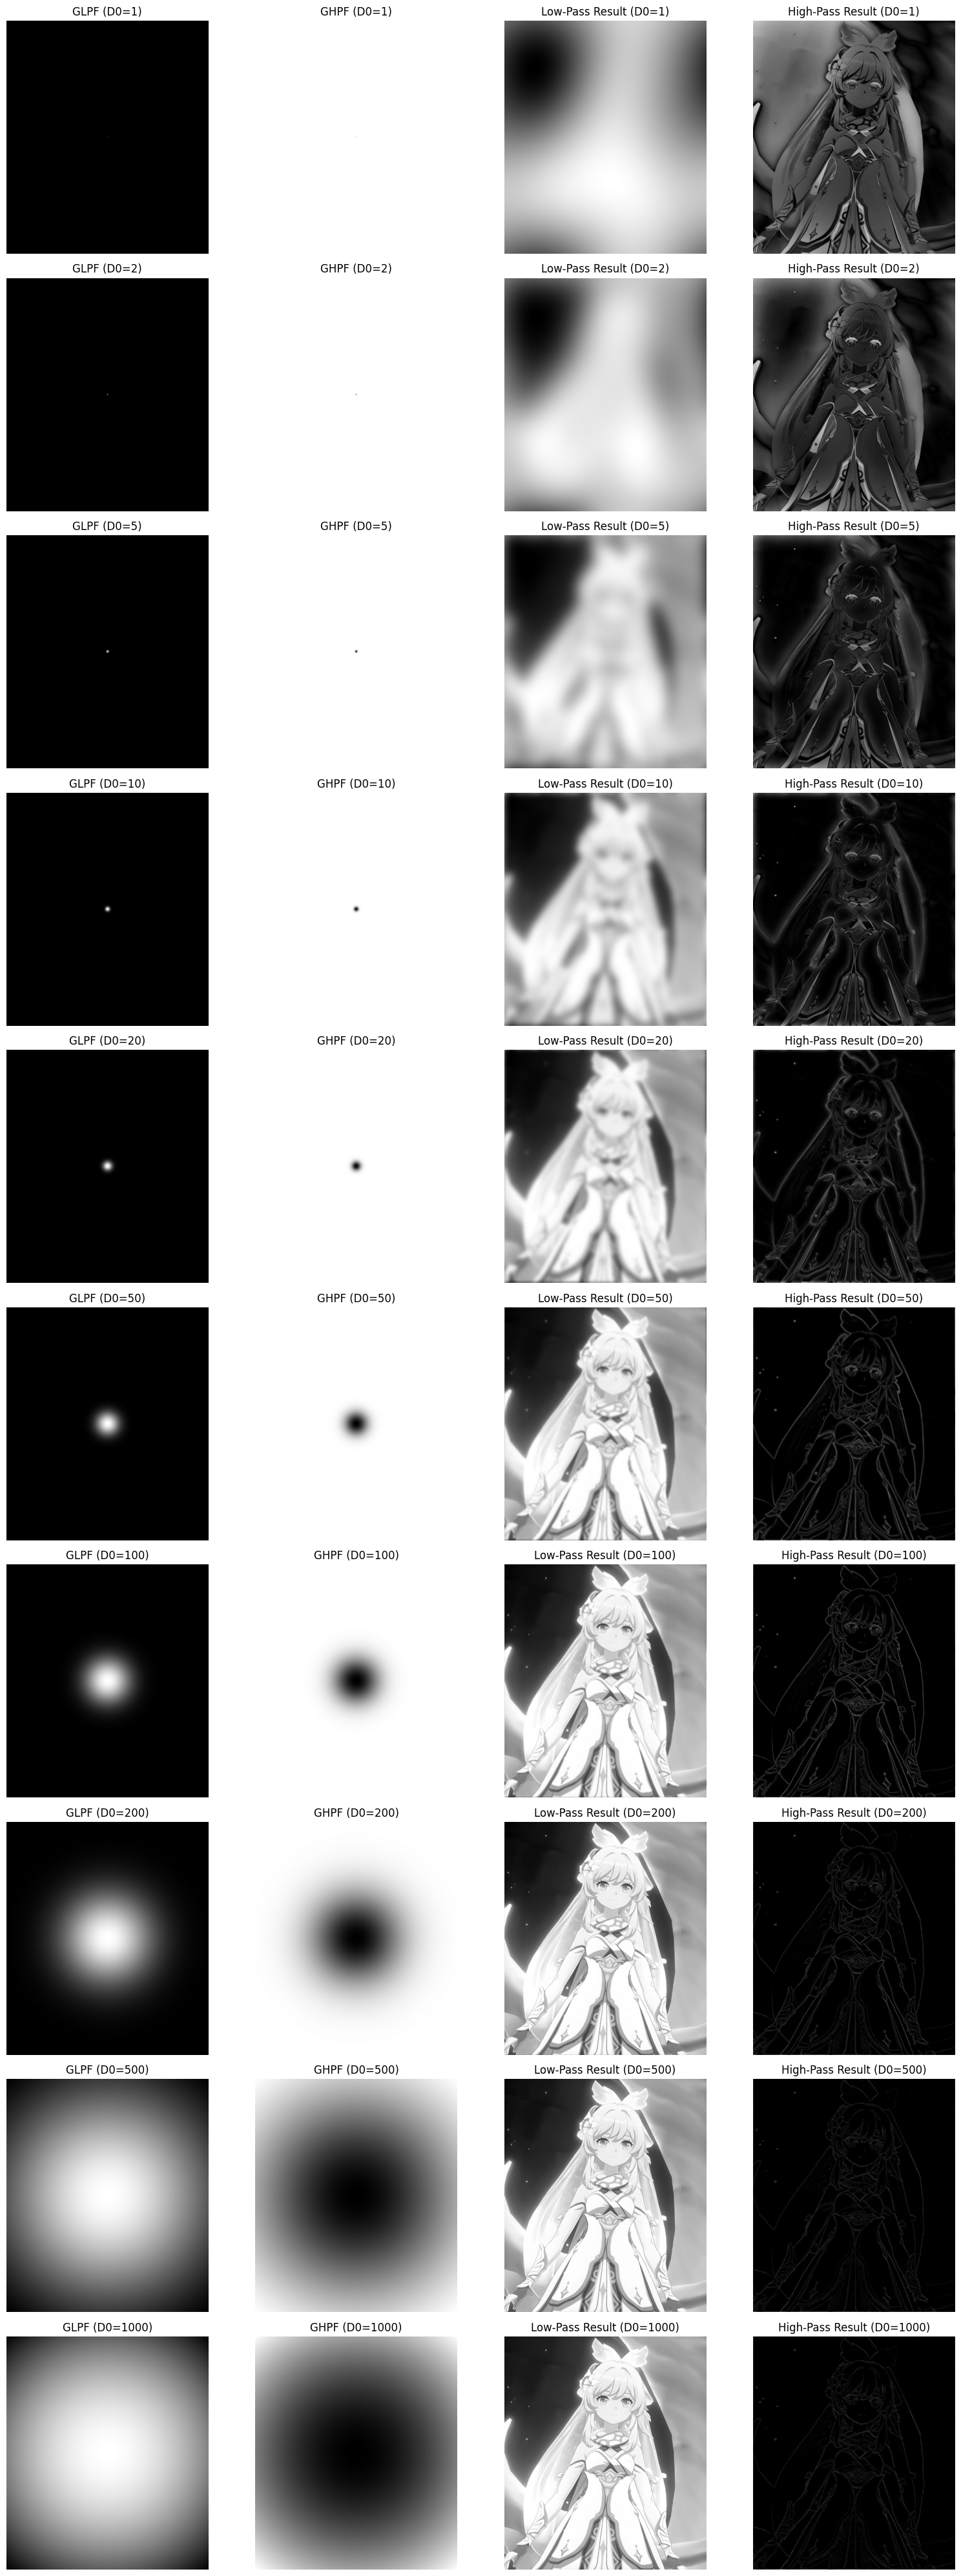

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 读取图像并转为灰度
img = cv2.imread('../assets/images/1.jpg', 1)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
rows, cols = gray.shape

# 傅里叶变换
f = np.fft.fft2(gray)
f_shift = np.fft.fftshift(f)

# 构建高斯低通滤波器（GLPF）
def gaussian_low_pass_filter(shape, cutoff):
    P, Q = shape
    H = np.zeros((P, Q))
    center = (P // 2, Q // 2)
    for u in range(P):
        for v in range(Q):
            D = np.sqrt((u - center[0])**2 + (v - center[1])**2)
            H[u, v] = np.exp(-D**2 / (2 * cutoff**2))
    return H

# 构建高斯高通滤波器（GHPF） = 1 - GLPF
def gaussian_high_pass_filter(shape, cutoff):
    return 1 - gaussian_low_pass_filter(shape, cutoff)

# 定义截止频率列表
cutoffs = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]

# 计算子图布局 - 修正计算方式
n_freq = len(cutoffs)
n_plots_per_freq = 4  # 每个频率需要4个图：GLPF, GHPF, 低通结果, 高通结果
total_plots = n_freq * n_plots_per_freq

# 为了更好的显示效果，使用 n_plots_per_freq 列
n_cols = n_plots_per_freq
n_rows = int(np.ceil(total_plots / n_cols))

plt.figure(figsize=(16, 4 * n_rows))

idx = 1  # 从第1个子图开始放置滤波结果

for i, D0 in enumerate(cutoffs):
    # 应用滤波器
    H_low = gaussian_low_pass_filter((rows, cols), D0)
    H_high = gaussian_high_pass_filter((rows, cols), D0)

    # 频域滤波
    G_low = f_shift * H_low
    G_high = f_shift * H_high

    # 逆变换回空域
    g_low = np.abs(np.fft.ifft2(np.fft.ifftshift(G_low)))
    g_high = np.abs(np.fft.ifft2(np.fft.ifftshift(G_high)))

    # 低通滤波器
    plt.subplot(n_rows, n_cols, idx)
    plt.imshow(H_low, cmap='gray')
    plt.title(f'GLPF (D0={D0})')
    plt.axis('off')
    idx += 1

    # 高通滤波器
    plt.subplot(n_rows, n_cols, idx)
    plt.imshow(H_high, cmap='gray')
    plt.title(f'GHPF (D0={D0})')
    plt.axis('off')
    idx += 1

    # 低通滤波后的图像
    plt.subplot(n_rows, n_cols, idx)
    plt.imshow(g_low, cmap='gray')
    plt.title(f'Low-Pass Result (D0={D0})')
    plt.axis('off')
    idx += 1

    # 高通滤波后的图像
    plt.subplot(n_rows, n_cols, idx)
    plt.imshow(g_high, cmap='gray')
    plt.title(f'High-Pass Result (D0={D0})')
    plt.axis('off')
    idx += 1

plt.tight_layout()
plt.savefig('../output/高斯滤波器.png', dpi=300)
plt.show()

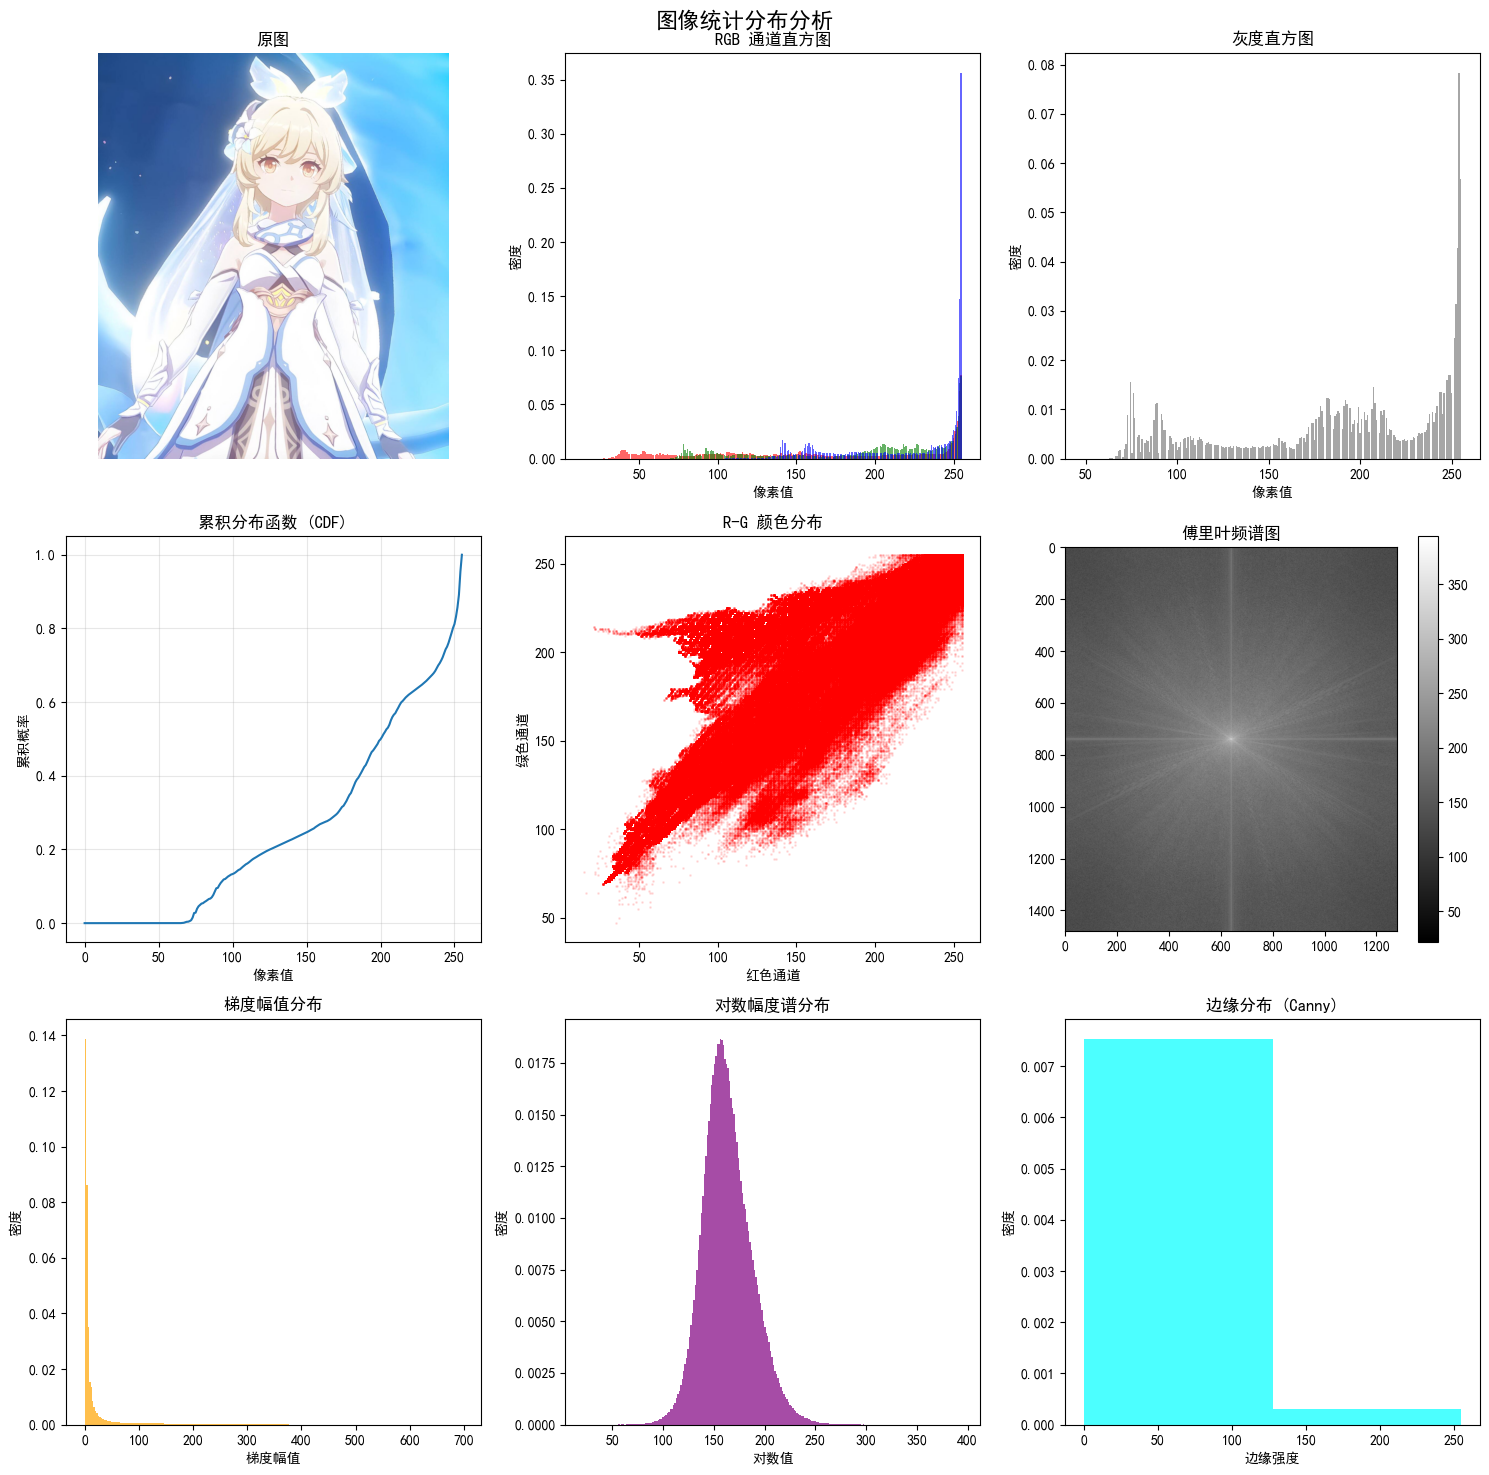

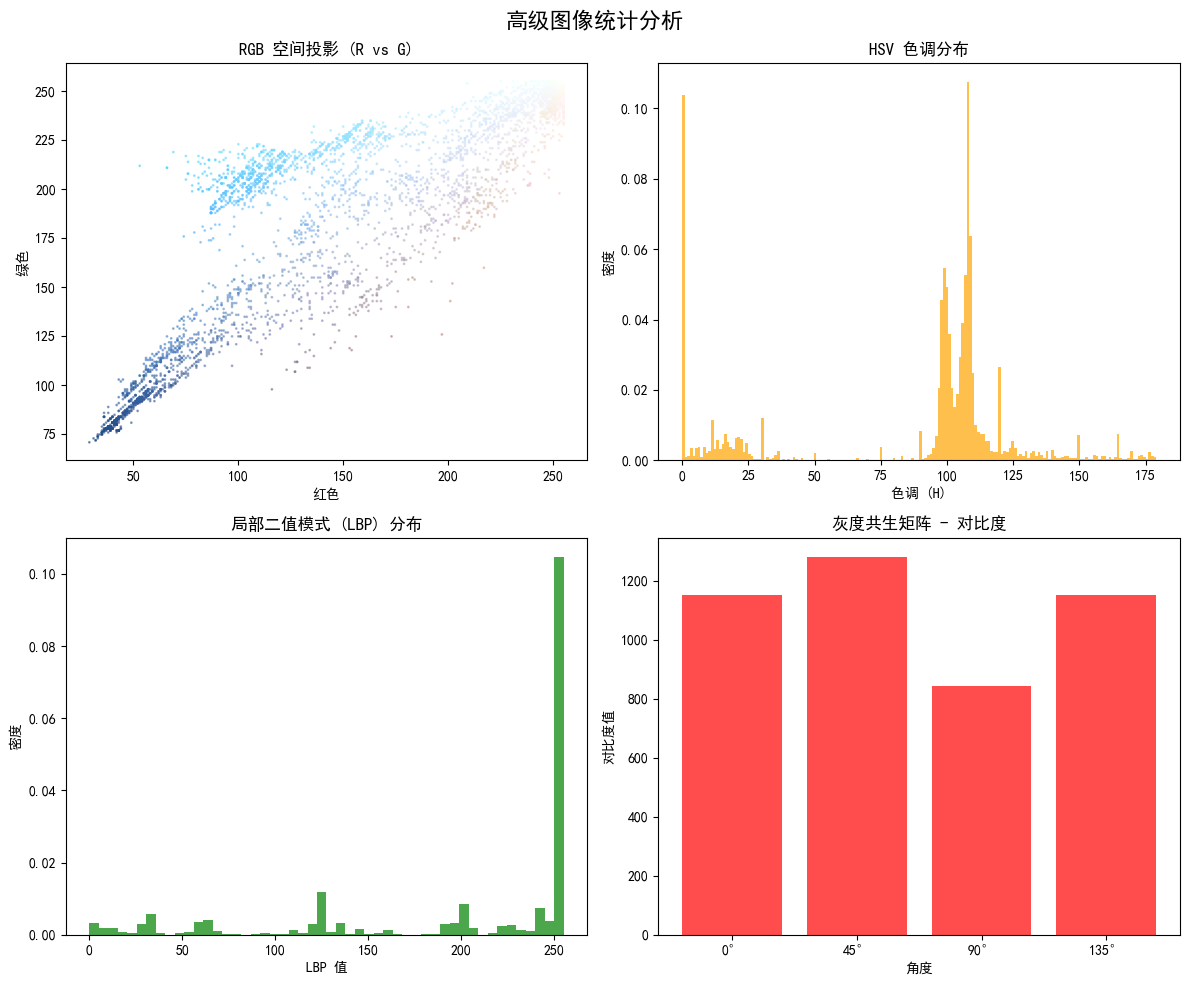

<Figure size 640x480 with 0 Axes>

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from matplotlib import rcParams

# 设置中文字体支持
rcParams['font.sans-serif'] = ['SimHei']
rcParams['axes.unicode_minus'] = False

def analyze_image_distributions(image_path):
    # 读取图像
    img = cv2.imread(image_path, 1)
    if img is None:
        raise FileNotFoundError(f"无法读取图像: {image_path}")
    
    # 转换为RGB格式用于matplotlib显示
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 转换为灰度图
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 计算傅里叶变换
    gray_float = np.float32(gray)
    dft = cv2.dft(gray_float, flags=cv2.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:,:,0], dft_shift[:,:,1]) + 1e-10)
    
    # 计算梯度
    grad_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    
    # 创建图形
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig.suptitle('图像统计分布分析', fontsize=16)
    
    # 1. 原图
    axes[0,0].imshow(img_rgb)
    axes[0,0].set_title('原图')
    axes[0,0].axis('off')
    
    # 2. RGB 通道直方图
    colors = ['red', 'green', 'blue']
    for i, color in enumerate(colors):
        ch = img_rgb[:,:,i].flatten()
        axes[0,1].hist(ch, bins=256, color=color, alpha=0.6, density=True)
    axes[0,1].set_title('RGB 通道直方图')
    axes[0,1].set_xlabel('像素值')
    axes[0,1].set_ylabel('密度')
    
    # 3. 灰度直方图
    axes[0,2].hist(gray.flatten(), bins=256, color='gray', alpha=0.7, density=True)
    axes[0,2].set_title('灰度直方图')
    axes[0,2].set_xlabel('像素值')
    axes[0,2].set_ylabel('密度')
    
    # 4. 累积分布函数 (CDF)
    hist, bins = np.histogram(gray.flatten(), bins=256, range=(0,256))
    cdf = np.cumsum(hist) / np.sum(hist)
    axes[1,0].plot(bins[:-1], cdf)
    axes[1,0].set_title('累积分布函数 (CDF)')
    axes[1,0].set_xlabel('像素值')
    axes[1,0].set_ylabel('累积概率')
    axes[1,0].grid(True, alpha=0.3)
    
    # 5. 2D 颜色分布图 (R vs G)
    axes[1,1].scatter(img_rgb[:,:,0].flatten(), img_rgb[:,:,1].flatten(), 
                     alpha=0.1, s=1, c='red')
    axes[1,1].set_title('R-G 颜色分布')
    axes[1,1].set_xlabel('红色通道')
    axes[1,1].set_ylabel('绿色通道')
    
    # 6. 傅里叶频谱图
    im = axes[1,2].imshow(magnitude_spectrum, cmap='gray')
    axes[1,2].set_title('傅里叶频谱图')
    plt.colorbar(im, ax=axes[1,2])
    
    # 7. 梯度幅值分布
    axes[2,0].hist(gradient_magnitude.flatten(), bins=256, color='orange', alpha=0.7, density=True)
    axes[2,0].set_title('梯度幅值分布')
    axes[2,0].set_xlabel('梯度幅值')
    axes[2,0].set_ylabel('密度')
    
    # 8. 对数幅度谱
    axes[2,1].hist(magnitude_spectrum.flatten(), bins=256, color='purple', alpha=0.7, density=True)
    axes[2,1].set_title('对数幅度谱分布')
    axes[2,1].set_xlabel('对数值')
    axes[2,1].set_ylabel('密度')
    
    # 9. 边缘强度分布 (使用Canny)
    edges = cv2.Canny(gray, 50, 150)
    axes[2,2].hist(edges.flatten(), bins=2, color='cyan', alpha=0.7, density=True)
    axes[2,2].set_title('边缘分布 (Canny)')
    axes[2,2].set_xlabel('边缘强度')
    axes[2,2].set_ylabel('密度')
    
    plt.tight_layout()
    plt.show()
    
    # 额外的高级分析
    fig2, axes2 = plt.subplots(2, 2, figsize=(12, 10))
    fig2.suptitle('高级图像统计分析', fontsize=16)
    
    # 1. RGB 3D 散点图（降采样以提高性能）
    h, w = img_rgb.shape[:2]
    sample_size = min(5000, h*w)  # 限制样本数量
    idx = np.random.choice(h*w, sample_size, replace=False)
    r_sample = img_rgb[:,:,0].flatten()[idx]
    g_sample = img_rgb[:,:,1].flatten()[idx]
    b_sample = img_rgb[:,:,2].flatten()[idx]
    
    # 由于matplotlib 2D限制，这里用2D投影
    axes2[0,0].scatter(r_sample, g_sample, c=np.stack([r_sample/255, g_sample/255, b_sample/255]).T, alpha=0.5, s=1)
    axes2[0,0].set_title('RGB 空间投影 (R vs G)')
    axes2[0,0].set_xlabel('红色')
    axes2[0,0].set_ylabel('绿色')
    
    # 2. HSV 分布
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    axes2[0,1].hist(hsv[:,:,0].flatten(), bins=180, color='orange', alpha=0.7, density=True)
    axes2[0,1].set_title('HSV 色调分布')
    axes2[0,1].set_xlabel('色调 (H)')
    axes2[0,1].set_ylabel('密度')
    
    # 3. 局部二值模式 (LBP) - 简化版本
    lbp_values = []
    for i in range(1, gray.shape[0]-1):
        for j in range(1, gray.shape[1]-1):
            center = gray[i, j]
            binary_str = ''.join([
                '1' if gray[i-1, j-1] >= center else '0',
                '1' if gray[i-1, j] >= center else '0',
                '1' if gray[i-1, j+1] >= center else '0',
                '1' if gray[i, j+1] >= center else '0',
                '1' if gray[i+1, j+1] >= center else '0',
                '1' if gray[i+1, j] >= center else '0',
                '1' if gray[i+1, j-1] >= center else '0',
                '1' if gray[i, j-1] >= center else '0'
            ])
            lbp_val = int(binary_str, 2)
            lbp_values.append(lbp_val)
    
    if lbp_values:  # 检查列表是否为空
        axes2[1,0].hist(lbp_values, bins=50, color='green', alpha=0.7, density=True)
        axes2[1,0].set_title('局部二值模式 (LBP) 分布')
        axes2[1,0].set_xlabel('LBP 值')
        axes2[1,0].set_ylabel('密度')
    
    # 4. 灰度共生矩阵 (GLCM) 特征 - 对比度
    from skimage.feature import graycomatrix, graycoprops
    
    # 为了加速，使用较小的图像
    small_gray = cv2.resize(gray, (50, 50))
    glcm = graycomatrix(small_gray, [1], [0, 45, 90, 135], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').flatten()
    
    axes2[1,1].bar(range(len(contrast)), contrast, color='red', alpha=0.7)
    axes2[1,1].set_title('灰度共生矩阵 - 对比度')
    axes2[1,1].set_xlabel('角度')
    axes2[1,1].set_ylabel('对比度值')
    axes2[1,1].set_xticks(range(len(contrast)))
    axes2[1,1].set_xticklabels(['0°', '45°', '90°', '135°'])
    
    plt.tight_layout()
    plt.show()
    plt.savefig('../output/图谱分析.png', dpi=300)

# 使用示例
analyze_image_distributions('../assets/images/1.jpg')